<a href="https://colab.research.google.com/github/adilsaleem007/Python-Basics-Assignment/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier


In [2]:
#load dataset
df = pd.read_csv('/content/bank-additional-full.csv')
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
#information and description of data
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [4]:
#separating categorical and numerical features
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns

print("Categorical Columns:\n", categorical_cols)
print("\nNumerical Columns:\n", numerical_cols)


Categorical Columns:
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

Numerical Columns:
 Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


In [5]:
#target variable distribution
df['y'].value_counts()


,count
y,
no,36548
yes,4640


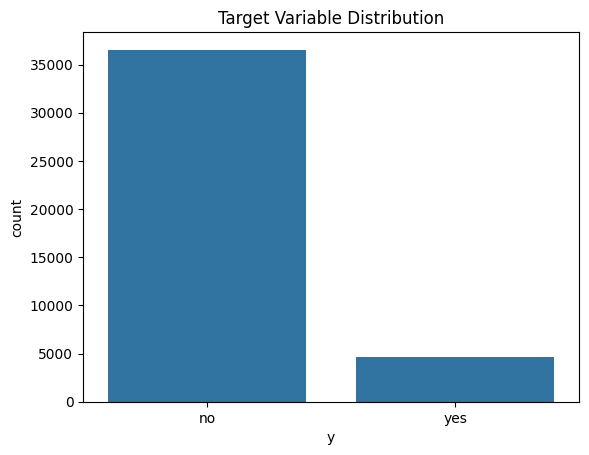

In [6]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()


In [7]:
#handling missing value
df.replace("unknown", np.nan, inplace=True)


In [8]:
#check for null values
df.isnull().sum()


,0
age,0
job,330
marital,80
education,1731
default,8597
housing,990
loan,990
contact,0
month,0
day_of_week,0


In [9]:
#handling null values
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-54059043.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [10]:
#confirming whether its solved
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [11]:
#encode target variable
df['y'] = df['y'].map({'yes':1, 'no':0})


In [12]:
#encode categorical value
df = pd.get_dummies(df, drop_first=True)


In [13]:
#splitting data into training and testing
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [14]:
#scaking
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [17]:
#defining function to evaluate models
def evaluate_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


In [18]:
#logistic regression
lr = LogisticRegression(max_iter=1000)
evaluate_model(lr)


Accuracy: 0.9099295945617868
Precision: 0.6595041322314049
Recall: 0.4267379679144385
F1 Score: 0.5181818181818182
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.66      0.43      0.52       935

    accuracy                           0.91      8238
   macro avg       0.79      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



In [19]:
#KNN
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn)


Accuracy: 0.8983976693372178
Precision: 0.5859649122807018
Recall: 0.3572192513368984
F1 Score: 0.44385382059800665
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7303
           1       0.59      0.36      0.44       935

    accuracy                           0.90      8238
   macro avg       0.75      0.66      0.69      8238
weighted avg       0.88      0.90      0.89      8238



In [20]:
#SVM
svm = SVC()
evaluate_model(svm)


Accuracy: 0.9077445982034474
Precision: 0.6611418047882136
Recall: 0.3839572192513369
F1 Score: 0.4857916102841678
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.66      0.38      0.49       935

    accuracy                           0.91      8238
   macro avg       0.79      0.68      0.72      8238
weighted avg       0.90      0.91      0.90      8238



In [21]:
#Decisiontree
dt = DecisionTreeClassifier()
evaluate_model(dt)


Accuracy: 0.8852876911871813
Precision: 0.49498997995991983
Recall: 0.5283422459893048
F1 Score: 0.5111226073460942
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7303
           1       0.49      0.53      0.51       935

    accuracy                           0.89      8238
   macro avg       0.72      0.73      0.72      8238
weighted avg       0.89      0.89      0.89      8238



In [22]:
#randomforest
rf = RandomForestClassifier()
evaluate_model(rf)


Accuracy: 0.911143481427531
Precision: 0.6443812233285917
Recall: 0.4844919786096257
F1 Score: 0.5531135531135531
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7303
           1       0.64      0.48      0.55       935

    accuracy                           0.91      8238
   macro avg       0.79      0.73      0.75      8238
weighted avg       0.90      0.91      0.91      8238



In [23]:
#bagging
bag = BaggingClassifier()
evaluate_model(bag)


Accuracy: 0.9107793153678078
Precision: 0.6347708894878706
Recall: 0.5037433155080214
F1 Score: 0.5617173524150268
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.63      0.50      0.56       935

    accuracy                           0.91      8238
   macro avg       0.79      0.73      0.76      8238
weighted avg       0.90      0.91      0.91      8238



In [24]:
#adaboost
ada = AdaBoostClassifier()
evaluate_model(ada)


Accuracy: 0.9038601602330663
Precision: 0.6166394779771615
Recall: 0.4042780748663102
F1 Score: 0.4883720930232558
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.62      0.40      0.49       935

    accuracy                           0.90      8238
   macro avg       0.77      0.69      0.72      8238
weighted avg       0.89      0.90      0.89      8238



In [25]:
#gradientboosting
gb = GradientBoostingClassifier()
evaluate_model(gb)


Accuracy: 0.9213401310997815
Precision: 0.694708276797829
Recall: 0.5475935828877005
F1 Score: 0.6124401913875598
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7303
           1       0.69      0.55      0.61       935

    accuracy                           0.92      8238
   macro avg       0.82      0.76      0.78      8238
weighted avg       0.92      0.92      0.92      8238



In [26]:
#comparing model result
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Bagging": BaggingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(results, columns=['Model','Accuracy','Precision','Recall','F1 Score'])
results_df.sort_values(by='F1 Score', ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score
7,Gradient Boosting,0.921340,0.694708,0.547594,0.612440
4,Random Forest,0.912115,0.654466,0.478075,0.552534
5,Bagging,0.904224,0.601671,0.462032,0.522686
0,Logistic Regression,0.909930,0.659504,0.426738,0.518182
3,Decision Tree,0.885773,0.496994,0.530481,0.513192
6,AdaBoost,0.903860,0.616639,0.404278,0.488372
2,SVM,0.907745,0.661142,0.383957,0.485792
1,KNN,0.898398,0.585965,0.357219,0.443854


In [28]:
#feature importance
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

importances = gb.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)



,Feature,Importance
1,duration,0.467489
9,nr.employed,0.276461
8,euribor3m,0.083007
3,pdays,0.047160
7,cons.conf.idx,0.030004
6,cons.price.idx,0.016994
36,month_mar,0.015727
39,month_oct,0.013912
46,poutcome_success,0.012141
0,age,0.009282


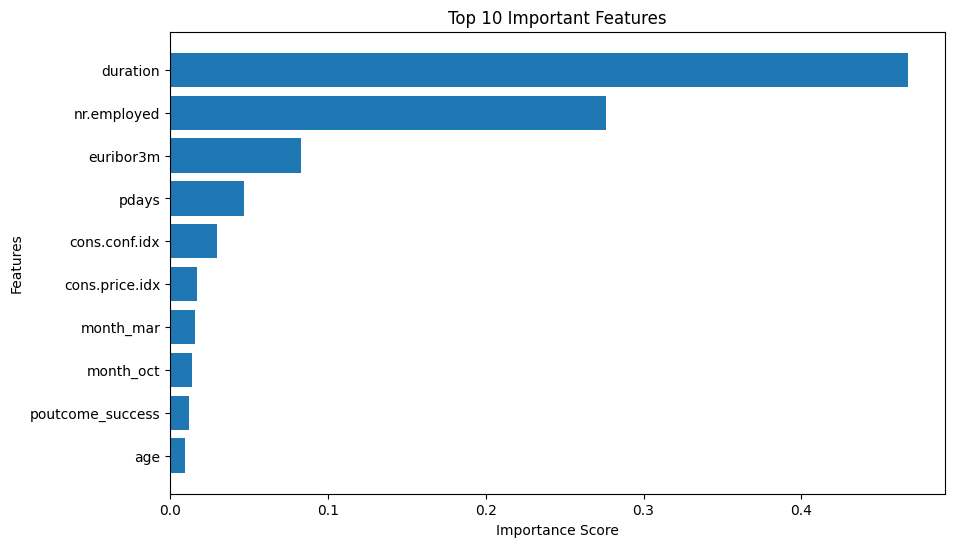

In [29]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'][:10],
         feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


# Insights
Based on the Gradient Boosting model, the most important features influencing customer subscription are:



*  Duration (Call duration)

*  Previous campaign outcome (poutcome)

*  Euribor3m (Interest rate)

*  Employment variation rate

*  Number of previous contacts






# Final conclusion
In this case study, multiple classification models were implemented to predict customer subscription to a term deposit.

Among all models, **Gradient Boosting** performed the best with the highest F1-score and accuracy.